# Generete 2D and 3D Model of Human

This is the main code accompanying the report "Predicting Body Segment Properties".
It estimates the mass and inertial properties of body segments for a procedurally generated human model.
The code outputs:

Printed values of the estimated parameters

A 2D visual plot of the generated person

Exported files required to visualize a 3D model in any URDF-compatible viewer.


In [1]:
#| default_exp human_result_module.py

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [3]:
#| export
from anthropmass.mass.massmain_module import *
from anthropmass.prediction_module import *
from anthropmass.anthro_module import *
from anthropmass.mass.massmesh_module import *
from anthropmass.mass.measurements_heights_module import *
from anthropmass.mass.massurdf_module import *
import pandas as pd

✅ Meshes exported to c:\Users\theo4\OneDrive\Skrivbord\bsp_estimation\anthropmass\anthropmass\mass\model_output


Below the main function for estimation of a person is estimated.  


 Uses estimated measurments df along with weight height and gender and feeds it to main function which provides estimations and 2D plot. 

In [4]:
#| export
def make_a_human(height:float, weight:float, gender:int):
    measurements=measurement_names()
    person = pd.DataFrame([{'weightkg': weight,'stature': height,'Gender': gender}])
    df = loop_measurements('xgboost',measurements, person)
    main(df, weight, height, gender)

Change the input values below to estimate your human!

Inputs:  
make_a_human(height, weight, gender)  
height in mm  
weight in kg  
gender, 0 for female, 1 for male.

Estimated paramaters for mass, COM positions, join center positions and moments of inertia are shown below. 

mass head 0.45460610362378306
volume upper trunk 0.0112644415472194
.......................................................
RESULTS:
Estimated Height (m): 1.7702025175094604
Actual Height (m): 1.76
Total Estimated Weight (kg) using Clauser regression model 88.51884634905281
Total Estimated Weight (kg) using Zatriosky regression model 87.15112
.......................................................

Positions of Body Segments (Custom Cartesian Mapping)

    Head Upper Trunk Middle Trunk Lower Trunk Upper Arm Lower Arm   Hand  Thigh  Shank   Foot
X      0           0            0           0         0         0      0      0      0      0
Y      0           0            0           0     0.207     0.207  0.207  0.073  0.073  0.073
Z  1.648       1.368        1.182       0.981     1.278     0.996   0.79  0.725  0.322  0.036
.......................................................

Joint Center Positions

  Shoulder  Elbow  Wrist    Hip   Knee  Ankle
X        0      0      0      0      0  

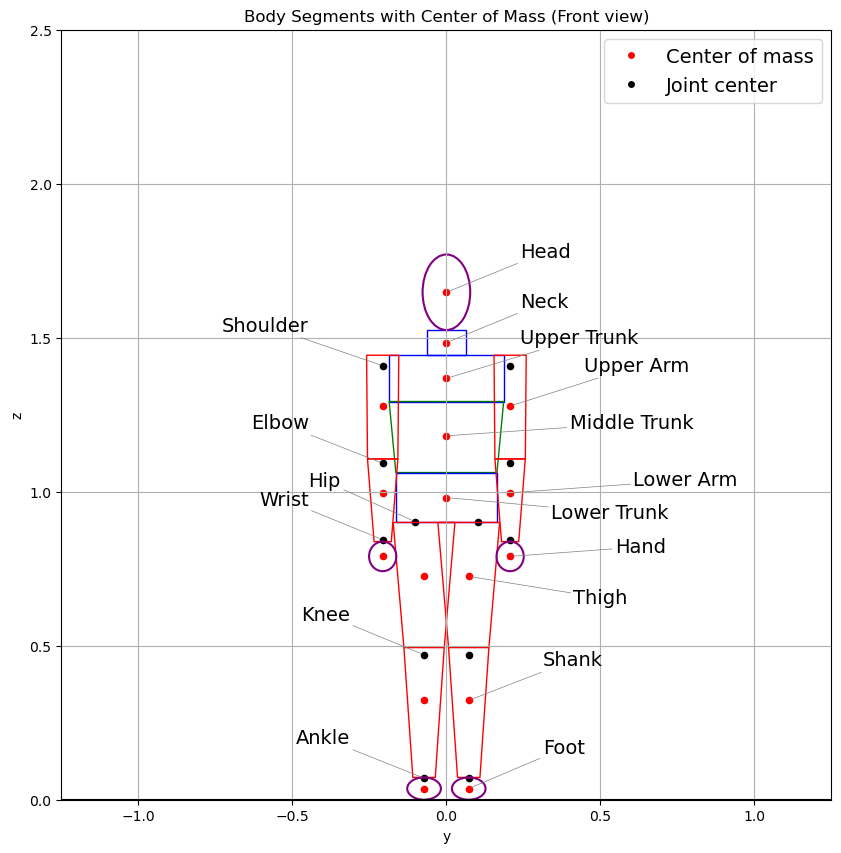

In [5]:
make_a_human(1760,86,1)

Below function for generating meshes and urdf files. Uses the same estimated measurments.

In [6]:
#| export
def generate_urdf_files(height:float, weight:float, gender:int):
    # 1) get the *raw* ANSUR row back out of your prediction
    measurements=measurement_names()
    persondf = pd.DataFrame([{'weightkg': weight,'stature': height,'Gender': gender}])
    person = loop_measurements('xgboost',measurements, persondf)

    # 2) compute just once for the meshes
    meas = get_measurements(person, height)

    # 3) write all the .stl’s
    generate_all_meshes(meas, height)
    print("Done")
    # 4) write the .urdf from the *raw* row, so it can call get_measurements again
    create_urdf(person, height)


Change the input values below to estimate a 3D model of your human!

Inputs:  
make_a_human(height, weight, gender)  
height in mm  
weight in kg  
gender, 0 for female, 1 for male.

In [7]:
generate_urdf_files(1900,70,0)

✅ Meshes exported to c:\Users\theo4\OneDrive\Skrivbord\bsp_estimation\anthropmass\anthropmass\mass\model_output
Done
✅ URDF written


Above is the direction of where meshes and urdf files are stored on your computer. Drag all these generated files into a compatible URDF viewer to see your human.

In [8]:
import nbdev; nbdev.nbdev_export()